<a href="https://colab.research.google.com/github/saumya8b-dev/awesome-website/blob/main/imggen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#fruit image generator
#people can generate fruit images like apple, banana, mango etc etc
#1: acquire a lot of fruit pics and label them
#2: clean the data
#3:create an image generation model
#4: train and test the model
#5: improve model
#but first learn to build a neural network at all

Loading local data assets...
Starting Conditional Vectorized GAN Loop...
-----------------------------------------------------------------
Epoch 01/5 | Critic Loss: 0.7831 | Artist Loss: 0.8015
Epoch 02/5 | Critic Loss: 0.7611 | Artist Loss: 0.7674
Epoch 03/5 | Critic Loss: 0.7366 | Artist Loss: 0.7927
Epoch 04/5 | Critic Loss: 0.6909 | Artist Loss: 0.8848
Epoch 05/5 | Critic Loss: 0.5797 | Artist Loss: 1.0549
-----------------------------------------------------------------
Conditional GAN Training Completed Successfully!

🎨 Commanding filters to render structural features for Digit: 2...


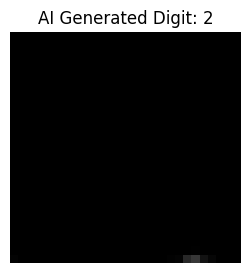

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 1. LOAD AND PROCESS LOCAL DATA (18,000 IMAGES)
# ==========================================================
print("Loading local data assets...")
data = pd.read_csv('sample_data/mnist_train_small.csv', header=None).to_numpy()
data_X = data[:, 1:] / 255.0
data_X = data_X.T

# Create our training partition pool
data_train_X = data_X[:, :18000].T.reshape(18000, 1, 28, 28)
data_train_Y = data[:, 0][:18000]
num_samples = 18000

def one_hot_encode(labels, num_classes=10):
    num_samples = labels.size
    one_hot = np.zeros((num_samples, num_classes))
    one_hot[np.arange(num_samples), labels.astype(int)] = 1
    return one_hot

data_train_Y_encoded = one_hot_encode(data_train_Y)

# ==========================================================
# 2. ACTIVATIONS & HELPER MATH FUNCTIONS
# ==========================================================
def leaky_relu(Z, alpha=0.1):
    return np.where(Z > 0, Z, alpha * Z)

def leaky_relu_derivative(Z, alpha=0.1):
    return np.where(Z > 0, 1.0, alpha)

def sigmoid(Z):
    return 1.0 / (1.0 + np.exp(-np.clip(Z, -500, 500)))

def im2col_indices(x_shape, kh, kw, stride=1, padding=0):
    N, C, H, W = x_shape
    out_h = (H + 2 * padding - kh) // stride + 1
    out_w = (W + 2 * padding - kw) // stride + 1
    i0 = np.repeat(np.arange(kh), kw)
    i0 = np.tile(i0, C)
    i1 = stride * np.repeat(np.arange(out_h), out_w)
    j0 = np.tile(np.arange(kw), kh * C)
    j1 = stride * np.tile(np.arange(out_w), out_h)
    i = i0.reshape(-1, 1) + i1.reshape(1, -1)
    j = j0.reshape(-1, 1) + j1.reshape(1, -1)
    k = np.repeat(np.arange(C), kh * kw).reshape(-1, 1)
    return k, i, j

# ==========================================================
# 3. VECTORIZED CONVOLUTION & PASS ENGINES
# ==========================================================
def vectorized_convolution(X, W, b, padding=0):
    n_filters, d_filter, f_h, f_w = W.shape
    n_x, _, img_h, img_w = X.shape

    if padding > 0:
        X = np.pad(X, ((0,0), (0,0), (padding, padding), (padding, padding)), mode='constant')
        _, _, img_h, img_w = X.shape

    out_h, out_w = img_h - f_h + 1, img_w - f_w + 1
    k, i, j = im2col_indices(X.shape, f_h, f_w)
    X_cols = X[:, k, i, j].transpose(1, 2, 0).reshape(d_filter * f_h * f_w, -1)

    Z = np.dot(W.reshape(n_filters, -1), X_cols) + b
    return Z.reshape(n_filters, out_h, out_w, n_x).transpose(3, 0, 1, 2)

def vectorized_max_pool(A, pool_size=2, stride=2):
    N, C, H, W = A.shape
    return A.reshape(N, C, H // pool_size, pool_size, W // pool_size, pool_size).max(axis=(3, 5))

def backward_dense(A2, Y, flattened_X, W2):
    m = Y.shape[1]
    dZ2 = A2 - Y
    dW2 = (1 / m) * np.dot(dZ2, flattened_X.T)
    dB2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)
    dFlattened = np.dot(W2.T, dZ2)
    return dZ2, dW2, dB2, dFlattened

def vectorized_backward_max_pool(dP1, A1, pool_size=2, stride=2):
    N, C, H, W = A1.shape
    out_h, out_w = H // pool_size, W // pool_size
    A1_reshaped = A1.reshape(N, C, out_h, pool_size, out_w, pool_size)
    mask = (A1_reshaped == A1_reshaped.max(axis=(3, 5), keepdims=True))
    return (dP1.reshape(N, C, out_h, 1, out_w, 1) * mask).reshape(N, C, H, W)

def backward_convolution(X, dZ1, W1, padding=0):
    n_filters, d_filter, f_h, f_w = W1.shape
    m = X.shape[0]

    if padding > 0:
        X = np.pad(X, ((0,0), (0,0), (padding, padding), (padding, padding)), mode='constant')

    dZ1_reshaped = dZ1.transpose(1, 2, 3, 0).reshape(n_filters, -1)
    k, i, j = im2col_indices(X.shape, f_h, f_w)
    X_cols = X[:, k, i, j].transpose(1, 2, 0).reshape(d_filter * f_h * f_w, -1)

    dW1 = (np.dot(dZ1_reshaped, X_cols.T) / m).reshape(W1.shape)
    dB1 = np.sum(dZ1_reshaped, axis=1, keepdims=True) / m

    W_flat = W1.reshape(n_filters, -1)
    dX_cols = np.dot(W_flat.T, dZ1_reshaped)

    dX = np.zeros_like(X)
    N, C, H, W = X.shape
    out_h, out_w = H - f_h + 1, W - f_w + 1

    dX_reshaped = dX_cols.reshape(C, f_h, f_w, N, out_h, out_w).transpose(3, 0, 4, 1, 5, 2)
    for fh in range(f_h):
        for fw in range(f_w):
            dX[:, :, fh:fh+out_h, fw:fw+out_w] += dX_reshaped[:, :, :, fh, :, fw]

    if padding > 0:
        dX = dX[:, :, padding:-padding, padding:-padding]
    return dW1, dB1, dX

# ==========================================================
# 4. UPSAMPLING & CONDITIONING ENGINE FUNCTIONS
# ==========================================================
def upsample_2x_batch(X):
    return np.repeat(np.repeat(X, 2, axis=2), 2, axis=3)

def backward_upsample_2x_batch(dX_out):
    return dX_out[:, :, ::2, ::2] + dX_out[:, :, 1::2, ::2] + dX_out[:, :, ::2, 1::2] + dX_out[:, :, 1::2, 1::2]

def label_condition_injection(latent_seeds, Y_encoded_labels):
    """Stretches One-Hot label vectors into matching spatial channel layers."""
    N, _, H, W = latent_seeds.shape
    labels_expanded = Y_encoded_labels[:, :, np.newaxis, np.newaxis]
    labels_spatial = np.tile(labels_expanded, (1, 1, H, W))
    return np.concatenate((latent_seeds, labels_spatial), axis=1)

# ==========================================================
# 5. PARAMETERS SETUP & ADAM OPTIMIZER INITIALIZATION
# ==========================================
W1_c, B1_c = np.random.randn(16, 1, 3, 3) * np.sqrt(2.0/9), np.zeros((16, 1))
W2_c, B2_c = np.random.randn(1, 2704) * np.sqrt(1.0/2704), np.zeros((1, 1))

# UPGRADED: W1_g configured to handle 11 feature maps (1 noise + 10 conditional labels)
W1_g, B1_g = np.random.randn(1, 11, 3, 3) * np.sqrt(2.0/(11 * 3 * 3)), np.zeros((1, 1))
W2_g, B2_g = np.random.randn(1, 1, 3, 3) * np.sqrt(2.0/9), np.zeros((1, 1))

m_W1_c, v_W1_c = np.zeros_like(W1_c), np.zeros_like(W1_c)
m_B1_c, v_B1_c = np.zeros_like(B1_c), np.zeros_like(B1_c)
m_W2_c, v_W2_c = np.zeros_like(W2_c), np.zeros_like(W2_c)
m_B2_c, v_B2_c = np.zeros_like(B2_c), np.zeros_like(B2_c)

m_W1_g, v_W1_g = np.zeros_like(W1_g), np.zeros_like(W1_g)
m_B1_g, v_B1_g = np.zeros_like(B1_g), np.zeros_like(B1_g)
m_W2_g, v_W2_g = np.zeros_like(W2_g), np.zeros_like(W2_g)
m_B2_g, v_B2_g = np.zeros_like(B2_g), np.zeros_like(B2_g)

def adam_step(W, B, dW, dB, m_W, v_W, m_B, v_B, t, lr=0.002):
    m_W = 0.9 * m_W + 0.1 * dW
    m_B = 0.9 * m_B + 0.1 * dB
    v_W = 0.999 * v_W + 0.001 * (dW ** 2)
    v_B = 0.999 * v_B + 0.001 * (dB ** 2)
    W -= lr * (m_W / (1.0 - 0.9**t)) / (np.sqrt(v_W / (1.0 - 0.999**t)) + 1e-8)
    B -= lr * (m_B / (1.0 - 0.9**t)) / (np.sqrt(v_B / (1.0 - 0.999**t)) + 1e-8)
    return W, B, m_W, v_W, m_B, v_B

# ==========================================================
# 6. CONDITIONAL ADVERSARIAL GAN LOOP WORKSPACE
# ==========================================================
epochs = 5
batch_size = 128
num_batches = num_samples // batch_size
t = 0

print("Starting Conditional Vectorized GAN Loop...")
print("-" * 65)

for epoch in range(epochs):
    permutation = np.random.permutation(num_samples)
    X_shuffled = data_train_X[permutation]
    Y_shuffled = data_train_Y_encoded[permutation]

    for b in range(num_batches):
        t += 1
        start_idx = b * batch_size
        X_real = X_shuffled[start_idx : start_idx + batch_size]
        Y_batch = Y_shuffled[start_idx : start_idx + batch_size]

        # --------------------------------------------------
        # STEP A: FORWARD ARTIST GENERATOR PASS
        # --------------------------------------------------
        latent_seeds = np.random.randn(batch_size, 1, 7, 7)
        # Inject the matching labels into the 11-channel stack block
        conditioned_input = label_condition_injection(latent_seeds, Y_batch)

        X_up1 = upsample_2x_batch(conditioned_input)
        Z_g1 = vectorized_convolution(X_up1, W1_g, B1_g, padding=1)
        A_g1 = leaky_relu(Z_g1)

        X_up2 = upsample_2x_batch(A_g1)
        Z_g2 = vectorized_convolution(X_up2, W2_g, B2_g, padding=1)
        X_fake = sigmoid(Z_g2)

        # --------------------------------------------------
        # STEP B: FORWARD CRITIC EVALUATION PASS
        # --------------------------------------------------
        Z1_r = vectorized_convolution(X_real, W1_c, B1_c)
        A1_r = leaky_relu(Z1_r)
        P1_r = vectorized_max_pool(A1_r)
        flat_r = P1_r.reshape(batch_size, -1).T
        A2_r = sigmoid(np.dot(W2_c, flat_r) + B2_c)

        Z1_f = vectorized_convolution(X_fake, W1_c, B1_c)
        A1_f = leaky_relu(Z1_f)
        P1_f = vectorized_max_pool(A1_f)
        flat_f = P1_f.reshape(batch_size, -1).T
        A2_f = sigmoid(np.dot(W2_c, flat_f) + B2_c)

        # --------------------------------------------------
        # STEP C: BACKWARD PASS — UPDATE CRITIC (EVERY 5 BATCHES)
        # --------------------------------------------------
        if b % 5 == 0:
            dZ2_r, dW2_c_r, dB2_c_r, dFlat_r = backward_dense(A2_r, np.ones((1, batch_size)) * 0.9, flat_r, W2_c)
            dZ2_f, dW2_c_f, dB2_c_f, dFlat_f = backward_dense(A2_f, np.zeros((1, batch_size)), flat_f, W2_c)

            dW2_c, dB2_c = dW2_c_r + dW2_c_f, dB2_c_r + dB2_c_f

            dP1_r = dFlat_r.T.reshape(batch_size, 16, 13, 13)
            dZ1_r = vectorized_backward_max_pool(dP1_r, A1_r) * leaky_relu_derivative(Z1_r)
            dW1_c_r, dB1_c_r, _ = backward_convolution(X_real, dZ1_r, W1_c)

            dP1_f = dFlat_f.T.reshape(batch_size, 16, 13, 13)
            dZ1_f = vectorized_backward_max_pool(dP1_f, A1_f) * leaky_relu_derivative(Z1_f)
            dW1_c_f, dB1_c_f, _ = backward_convolution(X_fake, dZ1_f, W1_c)

            dW1_c, dB1_c = dW1_c_r + dW1_c_f, dB1_c_r + dB1_c_f

            # Update Critic parameters slowly
            W1_c, B1_c, m_W1_c, v_W1_c, m_B1_c, v_B1_c = adam_step(
                W1_c, B1_c, dW1_c, dB1_c, m_W1_c, v_W1_c, m_B1_c, v_B1_c, t, lr=0.0002
            )
            W2_c, B2_c, m_W2_c, v_W2_c, m_B2_c, v_B2_c = adam_step(
                W2_c, B2_c, dW2_c, dB2_c, m_W2_c, v_W2_c, m_B2_c, v_B2_c, t, lr=0.0002
            )

        # --------------------------------------------------
        # STEP D: BACKWARD PASS — UPDATE ARTIST (EVERY BATCH)
        # --------------------------------------------------
        _, _, _, dX_fake_flat = backward_dense(A2_f, np.ones((1, batch_size)), flat_f, W2_c)
        dP1_g = dX_fake_flat.T.reshape(batch_size, 16, 13, 13)
        dZ1_g = vectorized_backward_max_pool(dP1_g, A1_f) * leaky_relu_derivative(Z1_f)

        # Pad the error grid layout cleanly by 2 pixels on each edge to expand bounds to 28x28
        dZ1_g_padded = np.pad(dZ1_g, ((0, 0), (0, 0), (2, 2), (2, 2)), mode='constant')
        dCanvas = vectorized_convolution(
            dZ1_g_padded,
            W1_c.transpose(1, 0, 2, 3)[:, :, ::-1, ::-1],
            np.zeros((1, 1))
        )

        # Perform element-wise Sigmoid derivative multiplication against the canvas
        dZ_g2 = dCanvas * (X_fake * (1.0 - X_fake))

        # Pass errors backward through Generator Layer 2
        dW2_g, dB2_g, dX_up2 = backward_convolution(X_up2, dZ_g2, W2_g, padding=1)
        dA_g1 = backward_upsample_2x_batch(dX_up2)

        # Pass errors backward through Generator Layer 1
        dZ_g1 = dA_g1 * leaky_relu_derivative(Z_g1)
        dW1_g, dB1_g, _ = backward_convolution(X_up1, dZ_g1, W1_g, padding=1)

        # Update Generator Parameters via Adam
        W1_g, B1_g, m_W1_g, v_W1_g, m_B1_g, v_B1_g = adam_step(
            W1_g, B1_g, dW1_g, dB1_g, m_W1_g, v_W1_g, m_B1_g, v_B1_g, t, lr=0.002
        )
        W2_g, B2_g, m_W2_g, v_W2_g, m_B2_g, v_B2_g = adam_step(
            W2_g, B2_g, dW2_g, dB2_g, m_W2_g, v_W2_g, m_B2_g, v_B2_g, t, lr=0.002
        )

    # --------------------------------------------------
    # MONITOR ADVERSARIAL LOSS METRICS (END OF EPOCH SUMMARY)
    # --------------------------------------------------
    loss_d = -np.mean(np.log(A2_r + 1e-8) + np.log(1.0 - A2_f + 1e-8))
    loss_g = -np.mean(np.log(A2_f + 1e-8))
    print(f"Epoch {epoch+1:02d}/{epochs} | Critic Loss: {loss_d:.4f} | Artist Loss: {loss_g:.4f}")

print("-" * 65)
print("Conditional GAN Training Completed Successfully!")

# ==========================================================
# 7. INTERACTIVE USER DEFINED INFERENCE GENERATION
# ==========================================================
while True:
    print("\n" + "=" * 50)
    user_input = input("Enter a digit (0-9) you want the AI to draw (or type 'exit' to quit): ")

    if user_input.lower() == 'exit':
        print("Closing generator. Excellent training run!")
        break

    if not user_input.isdigit() or not (0 <= int(user_input) <= 9):
        print("❌ Invalid entry! Please enter a single integer between 0 and 9.")
        continue

    target_digit = int(user_input)
    print(f"🎨 Commanding filters to render structural features for Digit: {target_digit}...")

    # Create an artificial 1D one-hot encoded array for our 1 test sample
    custom_label_vector = np.zeros((1, 10))
    custom_label_vector[0, target_digit] = 1.0

    # Generate fresh random latent noise map seed
    test_seed = np.random.randn(1, 1, 7, 7)

    # Feed into the conditional injection stack vector
    conditioned_test_input = label_condition_injection(test_seed, custom_label_vector)

    # Execute the forward pass through the conditioned generator weights
    X_up1_t = upsample_2x_batch(conditioned_test_input)
    Z_g1_t = vectorized_convolution(X_up1_t, W1_g, B1_g, padding=1)
    A_g1_t = leaky_relu(Z_g1_t)

    X_up2_t = upsample_2x_batch(A_g1_t)
    Z_g2_t = vectorized_convolution(X_up2_t, W2_g, B2_g, padding=1)
    final_output_pixels = sigmoid(Z_g2_t)

    # Isolate and plot the single image slice canvas matrix on your display
    plt.figure(figsize=(3, 3))
    plt.imshow(np.squeeze(final_output_pixels), cmap='gray', vmin=0.0, vmax=1.0)
    plt.title(f"AI Generated Digit: {target_digit}")
    plt.axis('off')
    plt.show()
